https://lopezyse.medium.com/knowledge-graphs-from-scratch-with-python-f3c2a05914cc

In [1]:
import pandas as pd

import networkx as nx
from node2vec import Node2Vec
import matplotlib.pyplot as plt

c:\Users\mikch\anaconda3\envs\KG\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


The first step is to load our data. In this example, we’ll create a simple KG from scratch. Let’s start by creating a dataframe with our data of interest.

In [2]:
# Define the heads, relations, and tails
head = ['drugA', 'drugB', 'drugC', 'drugD', 'drugA', 'drugC', 'drugD', 'drugE', 'gene1', 'gene2','gene3', 'gene4', 'gene50', 'gene2', 'gene3', 'gene4']
relation = ['treats', 'treats', 'treats', 'treats', 'inhibits', 'inhibits', 'inhibits', 'inhibits', 'associated', 'associated', 'associated', 'associated', 'associated', 'interacts', 'interacts', 'interacts']
tail = ['fever', 'hepatitis', 'bleeding', 'pain', 'gene1', 'gene2', 'gene4', 'gene20', 'obesity', 'heart_attack', 'hepatitis', 'bleeding', 'cancer', 'gene1', 'gene20', 'gene50']

# Create a dataframe
df = pd.DataFrame({'head': head, 'relation': relation, 'tail': tail})
df

,head,relation,tail
0,drugA,treats,fever
1,drugB,treats,hepatitis
2,drugC,treats,bleeding
3,drugD,treats,pain
4,drugA,inhibits,gene1
5,drugC,inhibits,gene2
6,drugD,inhibits,gene4
7,drugE,inhibits,gene20
8,gene1,associated,obesity
9,gene2,associated,heart_attack


Then, we create a NetworkX graph (G) to represent the KG. Each row in the DataFrame (df) corresponds to a triple (head, relation, tail) in the KG. The add_edge function adds edges between the head and tail entities, with the relation as a label.

In [3]:
# Create a knowledge graph
G = nx.Graph()
for _, row in df.iterrows():
    G.add_edge(row['head'], row['tail'], label=row['relation'])

Then, we plot the nodes (entities) and edges (relations) along with their labels.

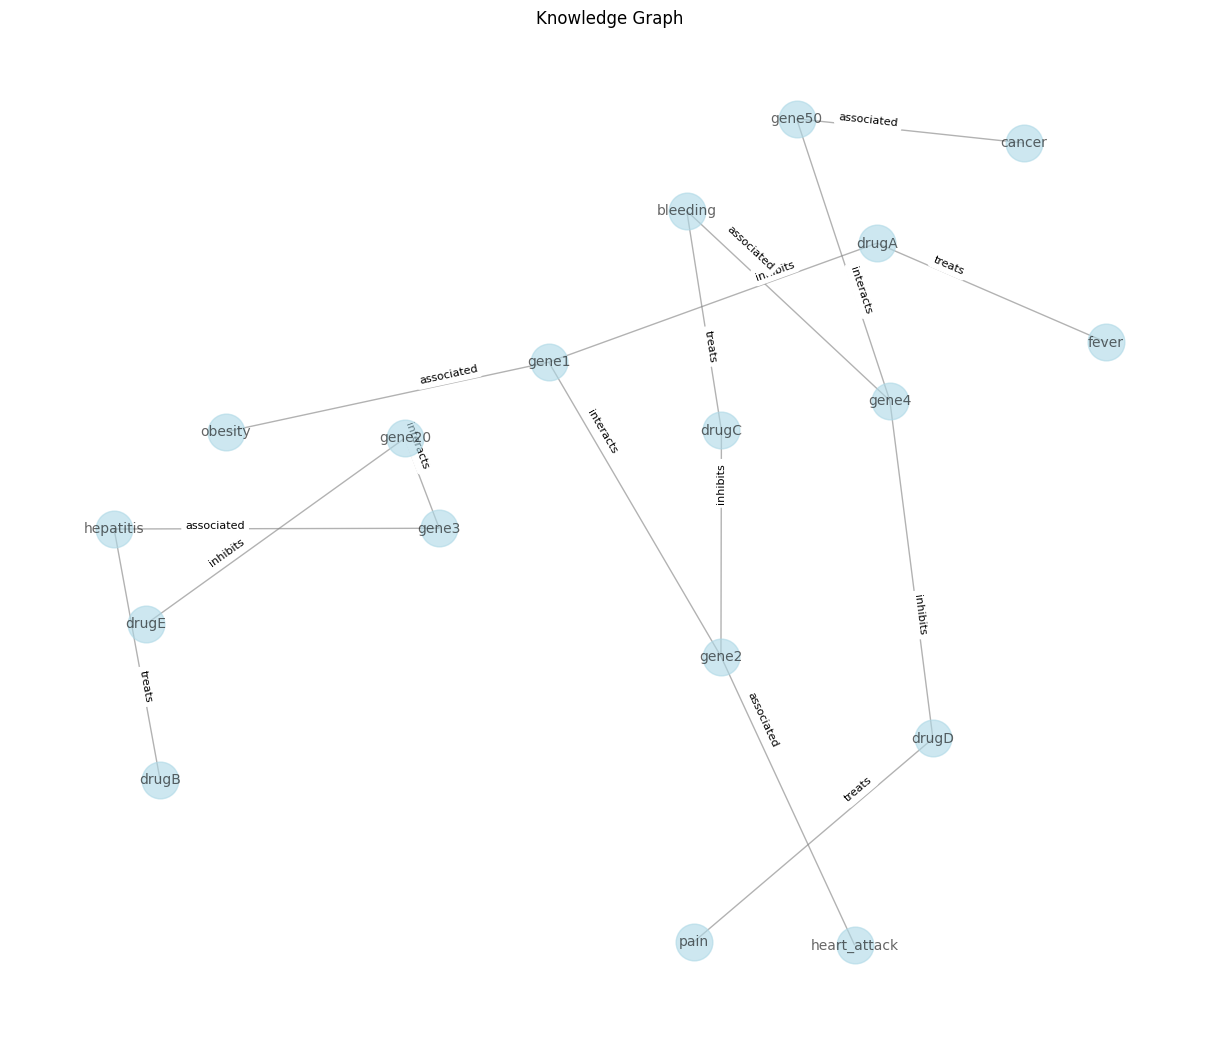

In [4]:
# Visualize the knowledge graph
pos = nx.spring_layout(G, seed=42, k=0.9)
labels = nx.get_edge_attributes(G, 'label')
plt.figure(figsize=(12, 10))
nx.draw(G, pos, with_labels=True, font_size=10, node_size=700, node_color='lightblue', edge_color='gray', alpha=0.6)
nx.draw_networkx_edge_labels(G, pos, edge_labels=labels, font_size=8, label_pos=0.3, verticalalignment='baseline')
plt.title('Knowledge Graph')
plt.show()

## Analyze it
The first thing we can do with our KG is to see how many nodes and edges it has and analyze their relationship.

In [5]:
num_nodes = G.number_of_nodes()
num_edges = G.number_of_edges()
print(f'Number of nodes: {num_nodes}')
print(f'Number of edges: {num_edges}')
print(f'Ratio edges to nodes: {round(num_edges / num_nodes, 2)}')

Number of nodes: 18
Number of edges: 16
Ratio edges to nodes: 0.89


## Node centrality analysis
Node centrality measures the importance or influence of a node within a graph. It helps identify nodes that are central to the structure of the graph. Some of the most common centrality measures are:

In [6]:
degree_centrality = nx.degree_centrality(G)
for node, centrality in degree_centrality.items():
    print(f'{node}: Degree Centrality = {centrality:.2f}')

drugA: Degree Centrality = 0.12
fever: Degree Centrality = 0.06
drugB: Degree Centrality = 0.06
hepatitis: Degree Centrality = 0.12
drugC: Degree Centrality = 0.12
bleeding: Degree Centrality = 0.12
drugD: Degree Centrality = 0.12
pain: Degree Centrality = 0.06
gene1: Degree Centrality = 0.18
gene2: Degree Centrality = 0.18
gene4: Degree Centrality = 0.18
drugE: Degree Centrality = 0.06
gene20: Degree Centrality = 0.12
obesity: Degree Centrality = 0.06
heart_attack: Degree Centrality = 0.06
gene3: Degree Centrality = 0.12
gene50: Degree Centrality = 0.12
cancer: Degree Centrality = 0.06


Betweenness centrality measures how often a node lies on the shortest path between other nodes, or in other words, the influence of a node on the flow of information between other nodes. Nodes with high betweenness centrality can act as bridges between different parts of the graph.

In [7]:
betweenness_centrality = nx.betweenness_centrality(G)
for node, centrality in betweenness_centrality.items():
    print(f'Betweenness Centrality of {node}: {centrality:.2f}')

Betweenness Centrality of drugA: 0.08
Betweenness Centrality of fever: 0.00
Betweenness Centrality of drugB: 0.00
Betweenness Centrality of hepatitis: 0.02
Betweenness Centrality of drugC: 0.26
Betweenness Centrality of bleeding: 0.26
Betweenness Centrality of drugD: 0.08
Betweenness Centrality of pain: 0.00
Betweenness Centrality of gene1: 0.21
Betweenness Centrality of gene2: 0.29
Betweenness Centrality of gene4: 0.26
Betweenness Centrality of drugE: 0.00
Betweenness Centrality of gene20: 0.02
Betweenness Centrality of obesity: 0.00
Betweenness Centrality of heart_attack: 0.00
Betweenness Centrality of gene3: 0.03
Betweenness Centrality of gene50: 0.08
Betweenness Centrality of cancer: 0.00


Closeness centrality quantifies how quickly a node can reach all other nodes in the graph. Nodes with higher closeness centrality are considered more central because they can communicate with other nodes more efficiently.

In [8]:
closeness_centrality = nx.closeness_centrality(G)
for node, centrality in closeness_centrality.items():
    print(f'Closeness Centrality of {node}: {centrality:.2f}')

Closeness Centrality of drugA: 0.18
Closeness Centrality of fever: 0.15
Closeness Centrality of drugB: 0.09
Closeness Centrality of hepatitis: 0.13
Closeness Centrality of drugC: 0.26
Closeness Centrality of bleeding: 0.26
Closeness Centrality of drugD: 0.19
Closeness Centrality of pain: 0.15
Closeness Centrality of gene1: 0.22
Closeness Centrality of gene2: 0.26
Closeness Centrality of gene4: 0.24
Closeness Centrality of drugE: 0.09
Closeness Centrality of gene20: 0.13
Closeness Centrality of obesity: 0.17
Closeness Centrality of heart_attack: 0.19
Closeness Centrality of gene3: 0.16
Closeness Centrality of gene50: 0.19
Closeness Centrality of cancer: 0.15


## Visualize node centrality measures

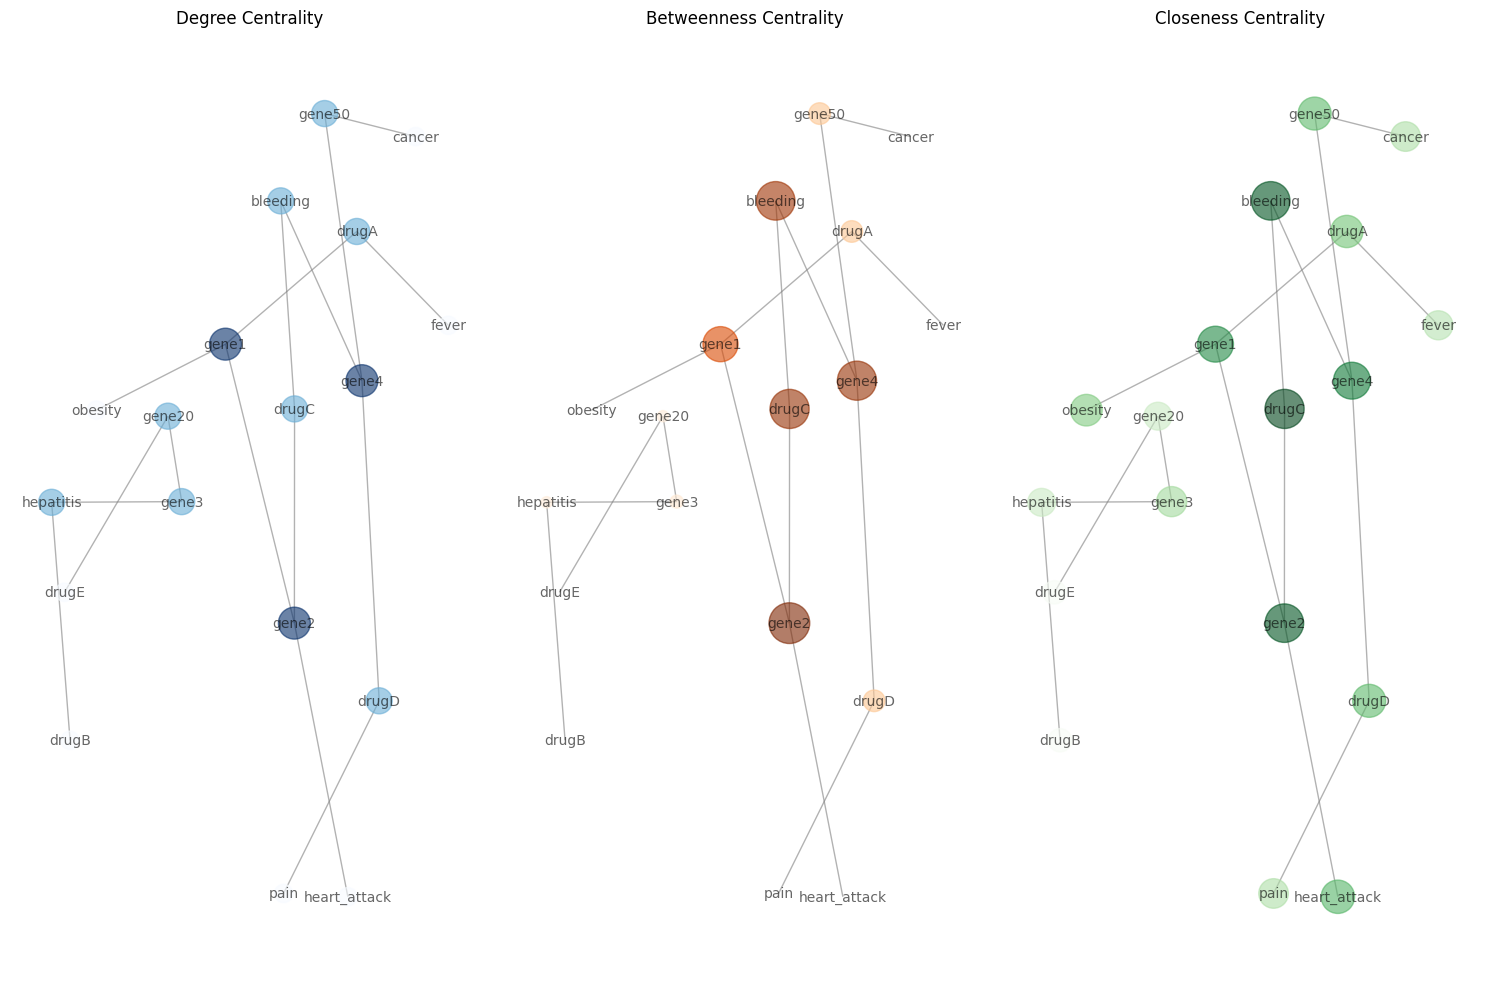

In [9]:
# Calculate centrality measures
degree_centrality = nx.degree_centrality(G)
betweenness_centrality = nx.betweenness_centrality(G)
closeness_centrality = nx.closeness_centrality(G)

# Visualize centrality measures
plt.figure(figsize=(15, 10))

# Degree centrality
plt.subplot(131)
nx.draw(G, pos, with_labels=True, font_size=10, node_size=[v * 3000 for v in degree_centrality.values()], node_color=list(degree_centrality.values()), cmap=plt.cm.Blues, edge_color='gray', alpha=0.6)
plt.title('Degree Centrality')

# Betweenness centrality
plt.subplot(132)
nx.draw(G, pos, with_labels=True, font_size=10, node_size=[v * 3000 for v in betweenness_centrality.values()], node_color=list(betweenness_centrality.values()), cmap=plt.cm.Oranges, edge_color='gray', alpha=0.6)
plt.title('Betweenness Centrality')

# Closeness centrality
plt.subplot(133)
nx.draw(G, pos, with_labels=True, font_size=10, node_size=[v * 3000 for v in closeness_centrality.values()], node_color=list(closeness_centrality.values()), cmap=plt.cm.Greens, edge_color='gray', alpha=0.6)
plt.title('Closeness Centrality')

plt.tight_layout()
plt.show()

## Shortest Path Analysis
Shortest path analysis focuses on finding the shortest path between two nodes in the graph. This can help you understand the connectivity between different entities and the minimum number of relationships required to connect them. For example, let’s say you want to find the shortest path between the nodes ‘gene2’ and ‘cancer’:

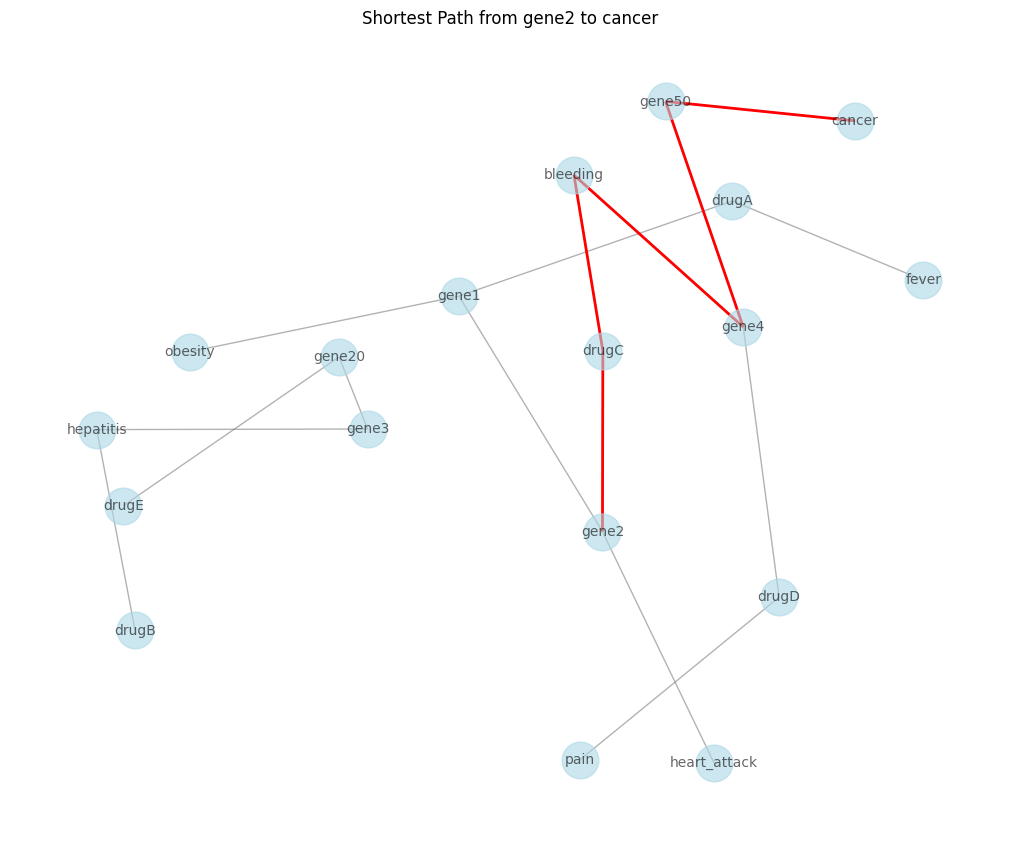

Shortest Path: ['gene2', 'drugC', 'bleeding', 'gene4', 'gene50', 'cancer']


In [10]:
source_node = 'gene2'
target_node = 'cancer'

# Find the shortest path
shortest_path = nx.shortest_path(G, source=source_node, target=target_node)

# Visualize the shortest path
plt.figure(figsize=(10, 8))
path_edges = [(shortest_path[i], shortest_path[i + 1]) for i in range(len(shortest_path) - 1)]
nx.draw(G, pos, with_labels=True, font_size=10, node_size=700, node_color='lightblue', edge_color='gray', alpha=0.6)
nx.draw_networkx_edges(G, pos, edgelist=path_edges, edge_color='red', width=2)
plt.title(f'Shortest Path from {source_node} to {target_node}')
plt.show()
print('Shortest Path:', shortest_path)

## Create Embeddings

Computing transition probabilities: 100%|██████████| 18/18 [00:00<00:00, 18048.64it/s]


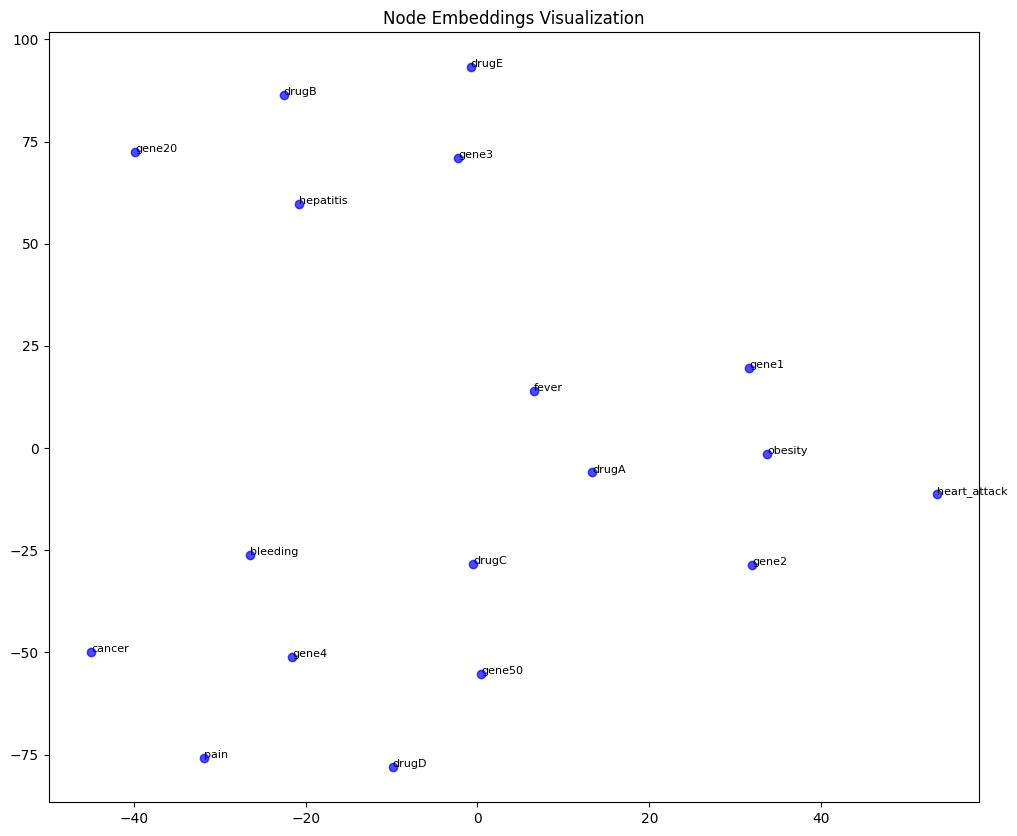

In [16]:
# Generate node embeddings using node2vec
node2vec = Node2Vec(G, dimensions=64, walk_length=30, num_walks=200, workers=4) # You can adjust these parameters
model = node2vec.fit(window=10, min_count=1, batch_words=4) # Training the model

# Visualize node embeddings using t-SNE
from sklearn.manifold import TSNE
import numpy as np

# Get embeddings for all nodes
embeddings = np.array([model.wv[node] for node in G.nodes()])

# Reduce dimensionality using t-SNE
tsne = TSNE(n_components=2, perplexity=10, max_iter=400)
embeddings_2d = tsne.fit_transform(embeddings)

# Visualize embeddings in 2D space with node labels
plt.figure(figsize=(12, 10))
plt.scatter(embeddings_2d[:, 0], embeddings_2d[:, 1], c='blue', alpha=0.7)

# Add node labels
for i, node in enumerate(G.nodes()):
    plt.text(embeddings_2d[i, 0], embeddings_2d[i, 1], node, fontsize=8)
plt.title('Node Embeddings Visualization')
plt.show()